# Heart Disease Prediction Using a Feedforward Neural Network

In [24]:
pip install ucimlrepo

In [25]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

# IMPORT LIBRARIES

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# COMBINE FEATURES + TARGET

In [27]:
df = pd.concat([X, y], axis=1)

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  


In [28]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


# CHECK MISSING VALUES

In [29]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


# FILL MISSING VALUES

In [30]:
df = df.fillna(df.mean(numeric_only=True))

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


# BINARY CLASSIFICATION

In [31]:
df['num'] = df['num'].apply(
    lambda x: 0 if x == 0 else 1
)

print(df['num'].value_counts())

num
0    164
1    139
Name: count, dtype: int64


# SPLIT FEATURES & LABELS

In [32]:
X = df.drop('num', axis=1)

y = df['num']

# FEATURE SCALING

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# TRAIN / VALIDATION / TEST SPLIT

In [34]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 242
Validation samples: 30
Testing samples: 31


In [35]:
# ==============================
# CONVERT TO TENSORS
# ==============================

X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train.values).view(-1, 1)
y_val = torch.FloatTensor(y_val.values).view(-1, 1)
y_test = torch.FloatTensor(y_test.values).view(-1, 1)

In [36]:
# ==============================
# DATA LOADERS
# ==============================

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [37]:
# ==============================
# BUILD NEURAL NETWORK
# ==============================

class HeartDiseaseNN(nn.Module):

    def __init__(self):
        super(HeartDiseaseNN, self).__init__()

        self.fc1 = nn.Linear(13, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))

        return x


model = HeartDiseaseNN()

print(model)

HeartDiseaseNN(
  (fc1): Linear(in_features=13, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [38]:
# ==============================
# LOSS FUNCTION & OPTIMIZER
# ==============================

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [39]:
# ==============================
# TRAIN MODEL
# ==============================

epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):

    # Training mode
    model.train()

    running_loss = 0.0

    for inputs, labels in train_loader:

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ======================
    # VALIDATION
    # ======================

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f} "
          f"Validation Loss: {avg_val_loss:.4f}")

Epoch [1/50] Train Loss: 0.7127 Validation Loss: 0.6942
Epoch [2/50] Train Loss: 0.6787 Validation Loss: 0.6625
Epoch [3/50] Train Loss: 0.6483 Validation Loss: 0.6270
Epoch [4/50] Train Loss: 0.6143 Validation Loss: 0.5806
Epoch [5/50] Train Loss: 0.5685 Validation Loss: 0.5208
Epoch [6/50] Train Loss: 0.5335 Validation Loss: 0.4537
Epoch [7/50] Train Loss: 0.4794 Validation Loss: 0.3941
Epoch [8/50] Train Loss: 0.4252 Validation Loss: 0.3407
Epoch [9/50] Train Loss: 0.4037 Validation Loss: 0.2997
Epoch [10/50] Train Loss: 0.4168 Validation Loss: 0.2696
Epoch [11/50] Train Loss: 0.3660 Validation Loss: 0.2561
Epoch [12/50] Train Loss: 0.3853 Validation Loss: 0.2440
Epoch [13/50] Train Loss: 0.3641 Validation Loss: 0.2380
Epoch [14/50] Train Loss: 0.3526 Validation Loss: 0.2300
Epoch [15/50] Train Loss: 0.3277 Validation Loss: 0.2229
Epoch [16/50] Train Loss: 0.3224 Validation Loss: 0.2174
Epoch [17/50] Train Loss: 0.3189 Validation Loss: 0.2140
Epoch [18/50] Train Loss: 0.3150 Validat

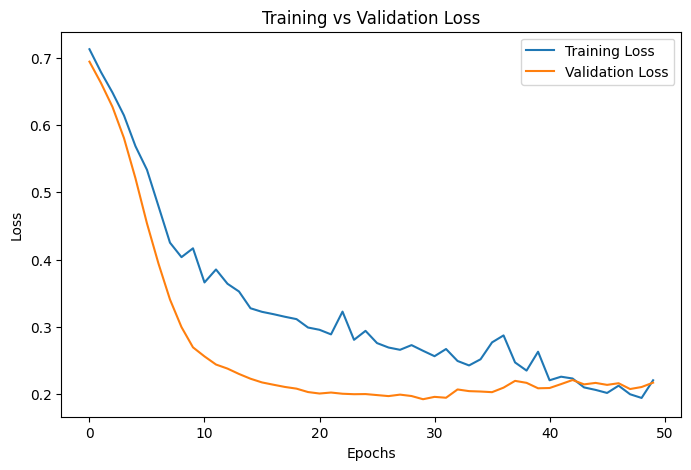

In [40]:
# ==============================
# LOSS GRAPH
# ==============================

plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [41]:
# ==============================
# TESTING
# ==============================

model.eval()

y_pred = []

with torch.no_grad():

    outputs = model(X_test)

    predictions = (outputs >= 0.5).float()

    y_pred = predictions.numpy()

# Convert actual labels
y_true = y_test.numpy()

# ACCURACY

In [42]:
accuracy = accuracy_score(y_true, y_pred)

print("Testing Accuracy:", accuracy * 100)

Testing Accuracy: 87.09677419354838


# CONFUSION MATRIX

In [43]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[14  3]
 [ 1 13]]


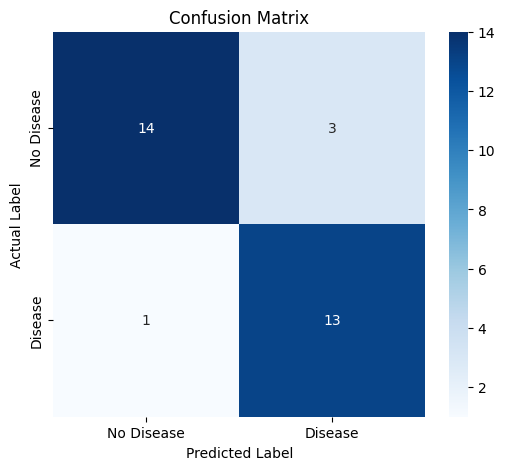

In [44]:
# ==============================
# CONFUSION MATRIX HEATMAP
# ==============================
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# CLASSIFICATION REPORT

In [45]:
report = classification_report(y_true, y_pred)

print(report)

              precision    recall  f1-score   support

         0.0       0.93      0.82      0.88        17
         1.0       0.81      0.93      0.87        14

    accuracy                           0.87        31
   macro avg       0.87      0.88      0.87        31
weighted avg       0.88      0.87      0.87        31



In [46]:
# ==============================
# PREDICTIONS VS ACTUAL
# ==============================

for i in range(10):

    print(f"Actual: {int(y_true[i][0])} | Predicted: {int(y_pred[i][0])}")

Actual: 1 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 1
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 0 | Predicted: 0
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 1
Actual: 1 | Predicted: 0
Actual: 0 | Predicted: 0
